Reported by: Natasha Flores (24-april-2025)

Exporting REACT results to shapefiles (a shapefile per year in this case)

Updated: 17-02-2026 Steven Kelderman

In [16]:
# Imports
import os
import sys
from pathlib import Path
import hashlib
import re

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xugrid as xu
import xarray as xr

# For this version to work you also need HYDROMT version 0.10.1
# This to work with the version of D-EcoImpact used in decoimpact_examples repository
sys.path.insert(1, r"C:\Users\kelde_sn\REPOS\decoimpact_examples\library")
from DEcoImpact_exp_func import DEIOutput


In [21]:
# Settings

ROOT_DIR = Path(r"P:\11211045-spongeworks\03_Model\03_wflow\REACT")  # Root directory of the project

# List with input locations of D-EcoImpact export file(s) containing REACT results to be converted
NETCDF_FILES: dict = {
    "eflows": ROOT_DIR / r"results\SpongeWorks\results_REACT_WFLOW_Eflows_Vecht_2017_2023.nc",
    "inundation_zones": ROOT_DIR / r"results\SpongeWorks\results_REACT_WFLOW_calibrate_flooding_zones_Step2_Vecht_2017_2023.nc",
    "inundation_zones_others": ROOT_DIR / r"results\SpongeWorks\results_REACT_WFLOW_flooding_zones_Step1_Vecht_2017-2023.nc",
    "nearbottomfv": ROOT_DIR / r"results\SpongeWorks\results_REACT_WFLOW_NearBottomFV_fishclasses_Vecht_2017_2023.nc"
    }

# Dictionary mapping original variable names in NetCDF to shortened names suitable for shapefile column constraints
RENAME_VARS_EFLOWS: dict = {
    'REACT_eflows_masked_Type_Low': 'low_flow', # Max 10 characters for shapefile column names
    'REACT_eflows_masked_Type_Inter': 'inter_flow',
    'REACT_eflows_masked_Type_High': 'high_flow',
                    }

    # list with variables that need to be exported to shapefile. Note, these should only contain faces as axes (no time or depth etc).
RENAME_VARS_INUNDATION: dict = {
    'pred_category_zone0_perc': 'Zone 0', # 0% 50% or 100% predicted
    'pred_category_zone1_perc': 'Zone 1',
    'pred_category_zone2_perc': 'Zone 2',
    'pred_category_zone3_perc': 'Zone 3',
    'pred_category_zone4_perc': 'Zone 4',
    'pred_category_zone5_perc': 'Zone 5',
    'pred_category_Hills_perc': 'Hills',
    }

# list with variables that need to be exported to shapefile. Note, these should only contain faces as axes (no time or depth etc).
RENAME_VARS_INUNDATION_OTHERS: dict = {
    'number_of_inundations_on_land': 'NInun_land',
    'number_of_dry_periods_in_river': 'NDry_river',
    'avg_dry_fall_duration_periods_in_river': 'DryDurRiver',
    }

# list with variables that need to be exported to shapefile. Note, these should only contain faces as axes (no time or depth etc).
RENAME_VARS_NEARBOTTOMFV: dict = {
    'REACT_guilds_nearbottom': 'guilds_NB',
    'AVG_water_depth_m': 'water_depth',
    'nearbottom_flow_velocity_ms': 'FlowVelNB',
    'AVG_flow_velocity_ms': 'AveFlowVel',
    'REACT_guilds': 'guilds_ADV',
    }


# Output path locations for shapefile data
OUTPUT_PATHS: dict = {
    "eflows": r"example_output_data_20260223/output_eflows",
    "inundation_zones": r"example_output_data_20260223/output_Inundation_Zones",
    "inundation_zones_others": r"example_output_data_20260223/output_Inundation_Zones_Others",
    "nearbottomfv": r"example_output_data_20260223/output_NearBottomFV",
}

# Create all output folders
for path in OUTPUT_PATHS.values():
    os.makedirs(path, exist_ok=True)


--- eflows ---
Data vars: ['INPUT_discharge_m3s', 'AVG_day_discharge_m3s', 'AVG_year_discharge_m3s', 'AVG_month_discharge_m3s_day_to_month', 'AVG_discharge_m3s_year_to_month', 'Percent_flow_perc', 'REACT_flow_regime_types', 'REACT_flow_regime_type1', 'REACT_flow_regime_type2', 'REACT_flow_regime_type3', 'Percent_flow_perc_type1', 'Percent_flow_perc_type2', 'Percent_flow_perc_type3', 'AVG_Percent_flow_perc_type1', 'AVG_Percent_flow_perc_type2', 'AVG_Percent_flow_perc_type3', 'yearly_watermask', 'REACT_eflows_Type_Low', 'REACT_eflows_Type_Inter', 'REACT_eflows_Type_High', 'water_indicator', 'REACT_eflows_masked_Type_Low', 'REACT_eflows_masked_Type_Inter', 'REACT_eflows_masked_Type_High']


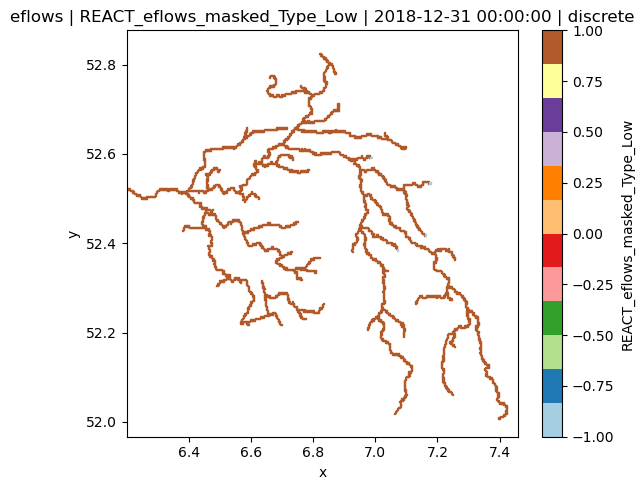


--- inundation_zones ---
Data vars: ['INPUT_min_waterdepth_m', 'INPUT_exposure_frac', 'lb_flooding_zone_category', 'ub_flooding_zone_category', 'pred_category_zone0', 'pred_category_zone1', 'pred_category_zone2', 'pred_category_zone3', 'pred_category_zone4', 'pred_category_zone5', 'pred_category_Hills', 'pred_category_zone0_perc', 'pred_category_zone1_perc', 'pred_category_zone2_perc', 'pred_category_zone3_perc', 'pred_category_zone4_perc', 'pred_category_zone5_perc', 'pred_category_Hills_perc']


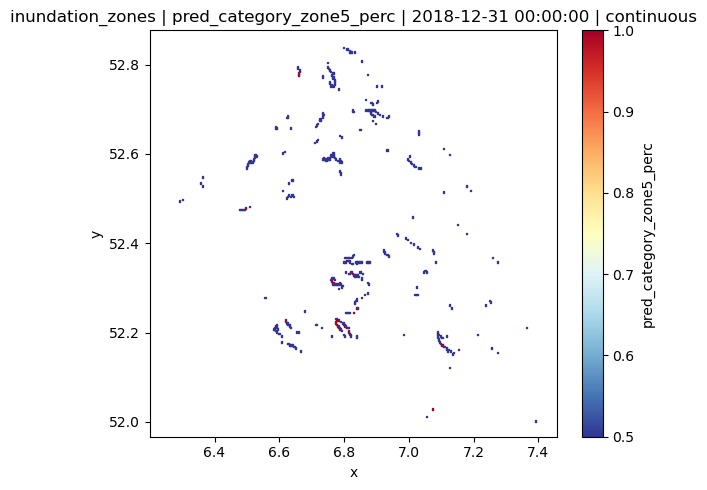


--- inundation_zones_others ---
Data vars: ['INPUT_river_water_depth_m', 'INPUT_overlandflow_water_depth_m', 'dry_fall_in_river', 'dry_fall_in_catchment', 'min_water_depth_whole_catchment_m', 'flooded_on_land', 'number_of_dry_periods_in_river', 'avg_dry_fall_duration_periods_in_river', 'min_water_depth_m', 'dry_fall_in_whole_catchment', 'number_of_inundations_on_land', 'exposure_frac']


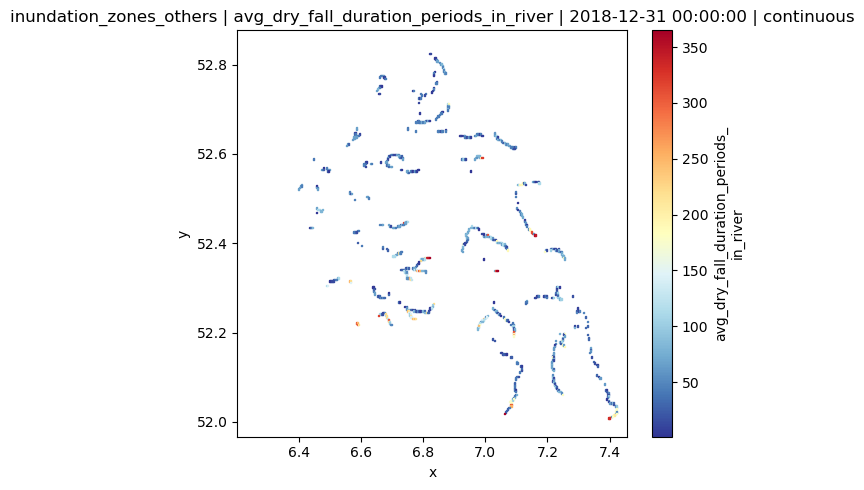


--- nearbottomfv ---
Data vars: ['INPUT_river_width_m', 'INPUT_water_depth_m', 'INPUT_discharge_m3s', 'INPUT_height_m', 'INPUT_flow_velocity_ms', 'AVG_water_depth_m', 'AVG_flow_velocity_ms', 'REACT_guilds', 'AVG_water_depth_m_cor', 'shear_flow_velocity_ms', 'nearbottom_flow_velocity_ms', 'REACT_guilds_nearbottom']


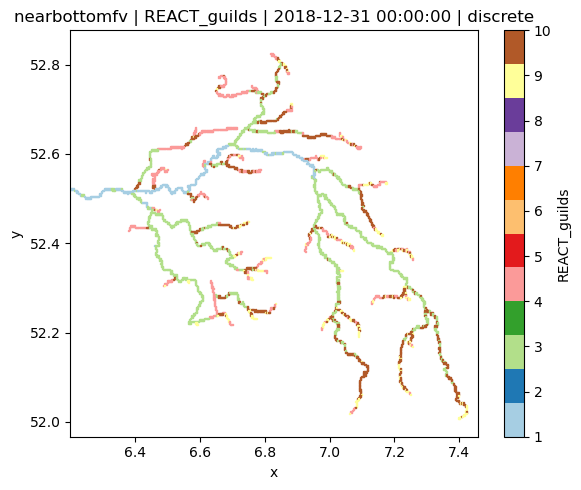

In [ ]:
# PLOT examples
def show_dataset_info_and_map(
    ds,
    var_name,
    var_type,
    time_coord,
    time_value,
    title,
    cmap=None,
):
    # Default colormap by variable type
    cmap_by_type = {
        "discrete": "Paired",
        "continuous": "RdYlBu_r",
    }
    var_type_l = str(var_type).lower()
    chosen_cmap = cmap or cmap_by_type.get(var_type_l, "viridis")

    print(f"\n--- {title} ---")
    print("Data vars:", list(ds.data_vars))
    # print("Coords:", list(ds.coords))
    # print(f"{time_coord} values:", list(ds[time_coord].values))

    da = ds[var_name].sel({time_coord: time_value})

    # Mask zeros for continuous variables
    if var_type_l == "continuous":
        da = da.where(da != 0)

    plt.figure(figsize=(6, 5))
    da.ugrid.plot(cmap=chosen_cmap)
    plt.title(f"{title} | {var_name} | {time_value} | {var_type}")
    plt.tight_layout()
    plt.show()

# eflows
uda_map_eflows = xu.open_mfdataset(NETCDF_FILES["eflows"])
show_dataset_info_and_map(
    ds=uda_map_eflows,
    var_name="REACT_eflows_masked_Type_Low",
    var_type="discrete",
    time_coord="time_month_year",
    time_value="2018-12-31 00:00:00",
    title="eflows",
)

# inundation_zones
uda_map_inundation_zones = xu.open_mfdataset(NETCDF_FILES["inundation_zones"])
show_dataset_info_and_map(
    ds=uda_map_inundation_zones,
    var_name="pred_category_zone5_perc",
    var_type="continuous",
    time_coord="time_year",
    time_value="2018-12-31 00:00:00",
    title="inundation_zones",
)

# inundation_zones_others
uda_map_inundation_zones_others = xu.open_mfdataset(NETCDF_FILES["inundation_zones_others"])
show_dataset_info_and_map(
    ds=uda_map_inundation_zones_others,
    var_name="avg_dry_fall_duration_periods_in_river",
    var_type="continuous",
    time_coord="time_year",
    time_value="2018-12-31 00:00:00",
    title="inundation_zones_others",
)

# nearbottomfv
uda_map_nearbottomfv = xu.open_mfdataset(NETCDF_FILES["nearbottomfv"])
show_dataset_info_and_map(
    ds=uda_map_nearbottomfv,
    var_name="REACT_guilds",
    var_type="discrete",
    time_coord="time_year",
    time_value="2018-12-31 00:00:00",
    title="nearbottomfv",
)


In [ ]:
# Datasets already loaded in previous cells
datasets = {
    "eflows": uda_map_eflows,
    "inundation_zones": uda_map_inundation_zones,
    "inundation_zones_others": uda_map_inundation_zones_others,
    "nearbottomfv": uda_map_nearbottomfv,
}

rename_maps = {
    "eflows": RENAME_VARS_EFLOWS,
    "inundation_zones": RENAME_VARS_INUNDATION,
    "inundation_zones_others": RENAME_VARS_INUNDATION_OTHERS,
    "nearbottomfv": RENAME_VARS_NEARBOTTOMFV,
}

# Store exported yearly nc paths per dataset
list_ds_in_per_year_all: dict[str, list[str]] = {}

for key, uda_map in datasets.items():
    rename_vars = rename_maps[key]

    # Rename and keep only target variables
    uda_map_renamed = uda_map.rename_vars(rename_vars)
    uda_map_subsetted = uda_map_renamed[list(rename_vars.values())]

    # Detect time coordinate
    if "time_month_year" in uda_map_subsetted.coords:
        time_coord = "time_month_year"
    elif "time_year" in uda_map_subsetted.coords:
        time_coord = "time_year"
    else:
        raise ValueError(f"No supported time coordinate found for '{key}'.")

    output_dir = OUTPUT_PATHS[key]
    os.makedirs(output_dir, exist_ok=True)

    yearly_files: list[str] = []
    for time_value in uda_map_subsetted[time_coord].values:
        time_subsetted_uda_map = uda_map_subsetted.sel({time_coord: time_value})
        year = time_value.astype("datetime64[Y]").astype(int) + 1970

        file_path = os.path.join(
            output_dir,
            f"results_REACT_WFLOW_{key}_{year}.nc"
        )
        yearly_files.append(file_path)

        print(f"[{key}] Exporting .nc file for {year}")
        time_subsetted_uda_map.ugrid.to_netcdf(file_path)

    list_ds_in_per_year_all[key] = yearly_files


[eflows] Exporting .nc file for year: 2017
[eflows] Exporting .nc file for year: 2018
[eflows] Exporting .nc file for year: 2019
[eflows] Exporting .nc file for year: 2020
[eflows] Exporting .nc file for year: 2021
[eflows] Exporting .nc file for year: 2022
[eflows] Exporting .nc file for year: 2023
[inundation_zones] Exporting .nc file for year: 2017
[inundation_zones] Exporting .nc file for year: 2018
[inundation_zones] Exporting .nc file for year: 2019
[inundation_zones] Exporting .nc file for year: 2020
[inundation_zones] Exporting .nc file for year: 2021
[inundation_zones] Exporting .nc file for year: 2022
[inundation_zones] Exporting .nc file for year: 2023
[inundation_zones_others] Exporting .nc file for year: 2017
[inundation_zones_others] Exporting .nc file for year: 2018
[inundation_zones_others] Exporting .nc file for year: 2019
[inundation_zones_others] Exporting .nc file for year: 2020
[inundation_zones_others] Exporting .nc file for year: 2021
[inundation_zones_others] Ex

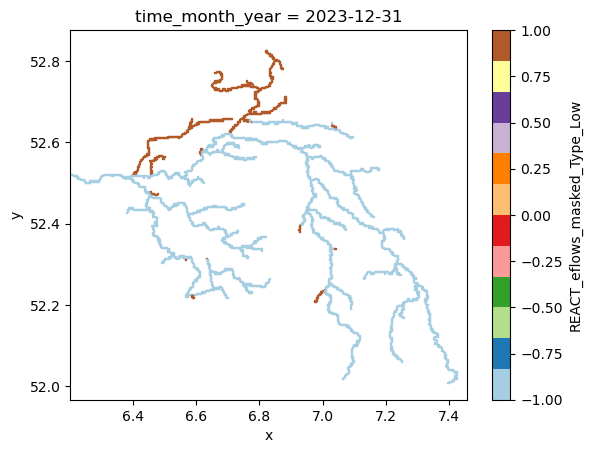

In [11]:
# Read and show result
# Show result of one specific year for 
uda_map_test = xu.open_mfdataset(list_ds_in_per_year_all["eflows"][-1])
uda_map_test["low_flow"].ugrid.plot(cmap = "Paired")


In [ ]:
# Export results to shapefile per year
for key in datasets:
    files = list_ds_in_per_year_all[key]
    files_to_export = files[1:] if len(files) > 1 else files  # Skip first year

    DEIresults = DEIOutput()
    DEIresults.set_root(root=os.getcwd(), mode="w+")
    DEIresults.set_paths_to_DEIresults(input_list_path=files_to_export)

    DEIresults.translate_UgridNetCDFs_to_Shape(
        list_variables=list(rename_maps[key].values()),
        output_path=OUTPUT_PATHS[key],
    )

    print(f"[{key}] Done.")

Start with example_output_data_20260223/output_eflows\results_REACT_WFLOW_eflows_2018.nc
Exported example_output_data_20260223/output_eflows\results_REACT_WFLOW_eflows_2018
Start with example_output_data_20260223/output_eflows\results_REACT_WFLOW_eflows_2019.nc
Exported example_output_data_20260223/output_eflows\results_REACT_WFLOW_eflows_2019
Start with example_output_data_20260223/output_eflows\results_REACT_WFLOW_eflows_2020.nc
Exported example_output_data_20260223/output_eflows\results_REACT_WFLOW_eflows_2020
Start with example_output_data_20260223/output_eflows\results_REACT_WFLOW_eflows_2021.nc
Exported example_output_data_20260223/output_eflows\results_REACT_WFLOW_eflows_2021
Start with example_output_data_20260223/output_eflows\results_REACT_WFLOW_eflows_2022.nc
Exported example_output_data_20260223/output_eflows\results_REACT_WFLOW_eflows_2022
Start with example_output_data_20260223/output_eflows\results_REACT_WFLOW_eflows_2023.nc
Exported example_output_data_20260223/output_e

In [ ]:
# Export results as geopackage per year

# CONFIGURATION

INPUT_DIRS = {
    "eflows": Path(r"example_output_data_20260223/output_eflows"),
    "inundation_zones": Path(r"example_output_data_20260223/output_Inundation_Zones"),
    "inundation_zones_others": Path(r"example_output_data_20260223/output_Inundation_Zones_Others"),
    "nearbottomfv": Path(r"example_output_data_20260223/output_NearBottomFV"),
}

# CRS constants
CRS_SOURCE = "EPSG:4326"   # Original CRS (WGS84)
CRS_AREA   = "EPSG:28992"  # Area-appropriate CRS for NL (meters)

# Functions

def find_yearly_shapefiles(root: Path) -> list[Path]:
    """Find all .shp files recursively under the given folder."""
    return sorted(root.rglob("*.shp"))

def extract_year_from_name(path: Path) -> int | None:
    """Extract the last 4-digit year from a filename's stem."""
    hits = re.findall(r"(19\d{2}|20\d{2})", path.stem)
    return int(hits[-1]) if hits else None

def ensure_source_crs(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    if gdf.crs is None:
        gdf = gdf.set_crs(CRS_SOURCE)
    return gdf

def to_area_crs(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    if gdf.crs is None:
        gdf = gdf.set_crs(CRS_SOURCE)
    if (gdf.crs.to_epsg() or "") != 28992:
        gdf = gdf.to_crs(CRS_AREA)
    return gdf

def ensure_area_columns(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    if "area_m2" not in gdf.columns:
        gdf["area_m2"] = gdf.geometry.area
    if "area_km2" not in gdf.columns:
        gdf["area_km2"] = gdf["area_m2"] / 1_000_000.0
    return gdf

def to_int_class(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    return s.round().astype("Int64")

def detect_cell_id_column(columns: list[str]) -> str | None:
    for c in ["cell_id", "CellID", "face_id", "FaceID", "fid",
              "mesh2d_face", "ugrid_face", "element", "elem_id", "poly_id"]:
        if c in columns:
            return c
    return None

def make_geom_hash(geom) -> str:
    return hashlib.md5(geom.wkb).hexdigest()


# PROCESS ALL INPUT_DIRS

all_results = {}

for source_name, input_root in INPUT_DIRS.items():
    print(f"\n🔍 Processing source: '{source_name}' in {input_root}")
    shp_files = find_yearly_shapefiles(input_root)
    if not shp_files:
        print(f"⚠️ No shapefiles found for '{source_name}' in {input_root}")
        continue

    records = []
    for shp in shp_files:
        year = extract_year_from_name(shp)
        if year is None:
            continue

        try:
            gdf = gpd.read_file(shp)
        except Exception as e:
            print(f"⚠️ Could not read {shp}: {e}")
            continue

        gdf = ensure_source_crs(gdf)
        try:
            gdf["geometry"] = gdf.geometry.buffer(0)
        except Exception:
            pass

        gdf = to_area_crs(gdf)
        gdf["year"] = int(year)
        gdf["source_name"] = source_name
        gdf["source_folder"] = str(shp.parent.resolve())
        gdf = ensure_area_columns(gdf)

        records.append(gdf)

    if not records:
        print(f"⚠️ No valid yearly records for '{source_name}'")
        continue

    gdf_all = gpd.GeoDataFrame(pd.concat(records, ignore_index=True), crs=CRS_AREA)

    id_col = detect_cell_id_column(gdf_all.columns)
    if id_col is None:
        gdf_all["cell_id"] = gdf_all.geometry.apply(make_geom_hash)
        id_col = "cell_id"

    # Export per folder-year
    exported = 0
    seen = set()
    for shp_path in shp_files:
        year_i = extract_year_from_name(shp_path)
        if year_i is None:
            continue

        folder = shp_path.parent.resolve()
        key = (str(folder), int(year_i))
        if key in seen:
            continue
        seen.add(key)

        gdf_year = gdf_all[
            (gdf_all["year"] == int(year_i)) &
            (gdf_all["source_folder"] == str(folder))
        ].copy()

        if gdf_year.empty:
            continue

        folder_gpkg = folder / f"{folder.name}_28992.gpkg"
        if folder_gpkg.exists():
            folder_gpkg.unlink()

        layer_name = f"{source_name}_all_years"
        gdf_year.to_file(folder_gpkg, layer=layer_name, driver="GPKG")
        exported += 1

    # Export combined per source
    combined_layer = f"{source_name}_all_years"
    combined_gpkg = input_root / f"{source_name}_28992_all_years.gpkg"

    if combined_gpkg.exists():
        combined_gpkg.unlink()
    gdf_all.to_file(combined_gpkg, layer=combined_layer, driver="GPKG")

    print(f"✅ [{source_name}] wrote {exported} folder GPKG export(s)")
    print(f"✅ [{source_name}] wrote combined layer '{combined_layer}' to {combined_gpkg}")

    all_results[source_name] = {
        "gdf_all": gdf_all,
        "id_col": id_col,
        "combined_gpkg": combined_gpkg,
        "combined_layer": combined_layer,
    }


🔍 Processing source: 'eflows' in example_output_data_20260223\output_eflows
✅ [eflows] wrote 6 folder GPKG export(s)
✅ [eflows] wrote combined layer 'eflows_all_years' to example_output_data_20260223\output_eflows\eflows_28992_all_years.gpkg

🔍 Processing source: 'inundation_zones' in example_output_data_20260223\output_Inundation_Zones
✅ [inundation_zones] wrote 6 folder GPKG export(s)
✅ [inundation_zones] wrote combined layer 'inundation_zones_all_years' to example_output_data_20260223\output_Inundation_Zones\inundation_zones_28992_all_years.gpkg

🔍 Processing source: 'inundation_zones_others' in example_output_data_20260223\output_Inundation_Zones_Others
✅ [inundation_zones_others] wrote 6 folder GPKG export(s)
✅ [inundation_zones_others] wrote combined layer 'inundation_zones_others_all_years' to example_output_data_20260223\output_Inundation_Zones_Others\inundation_zones_others_28992_all_years.gpkg

🔍 Processing source: 'nearbottomfv' in example_output_data_20260223\output_NearBo